In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

data = pd.read_csv("CSS-300_CourseProject_V2.csv", low_memory=False)

In [2]:
data.head()

,Player,Season,WAR,H,ER,HR,BB,SO,ERA+,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB
0,Roger Clemens,1990,10.4,193,49,7,54,209,211,2.18,1.082,7.6,0.3,2.1,8.2,3.87
1,Roger Clemens,1991,7.9,219,79,15,65,241,165,2.57,1.047,7.3,0.5,2.2,8.0,3.71
2,Roger Clemens,1992,8.7,203,66,11,62,208,174,2.54,1.074,7.4,0.4,2.3,7.6,3.35
3,Roger Clemens,1993,2.6,175,95,17,67,160,104,3.69,1.263,8.2,0.8,3.1,7.5,2.39
4,Roger Clemens,1994,6.0,124,54,15,71,168,176,3.62,1.143,6.5,0.8,3.7,8.9,2.37


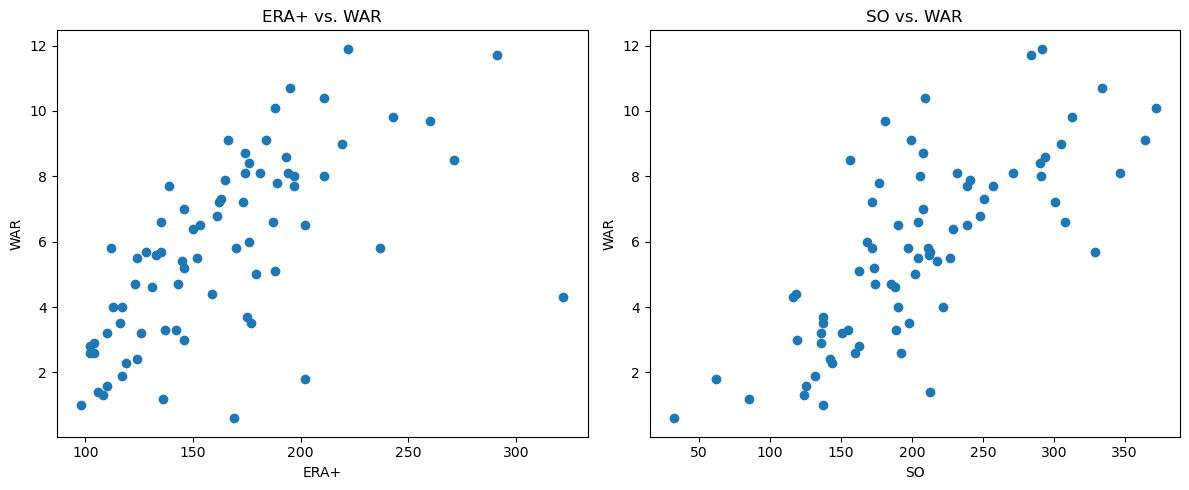

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(data['ERA+'], data['WAR'])
ax1.set_title("ERA+ vs. WAR")
ax1.set_xlabel("ERA+")
ax1.set_ylabel("WAR")

ax2.scatter(data['SO'], data['WAR'])
ax2.set_title("SO vs. WAR")
ax2.set_xlabel("SO")
ax2.set_ylabel("WAR")

plt.tight_layout()
plt.show()

In [5]:
X = data[['ERA+', 'SO']]  
y = data['WAR'] 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [8]:
predictions = model.predict(X_test)

print('R-squared:', metrics.r2_score(y_test, predictions))
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

R-squared: 0.7172220764811221
MAE: 1.153057455133921
RMSE: 1.4681952387618065
Intercept: -3.6443669414930966
Coefficients: [0.02409487 0.02672891]


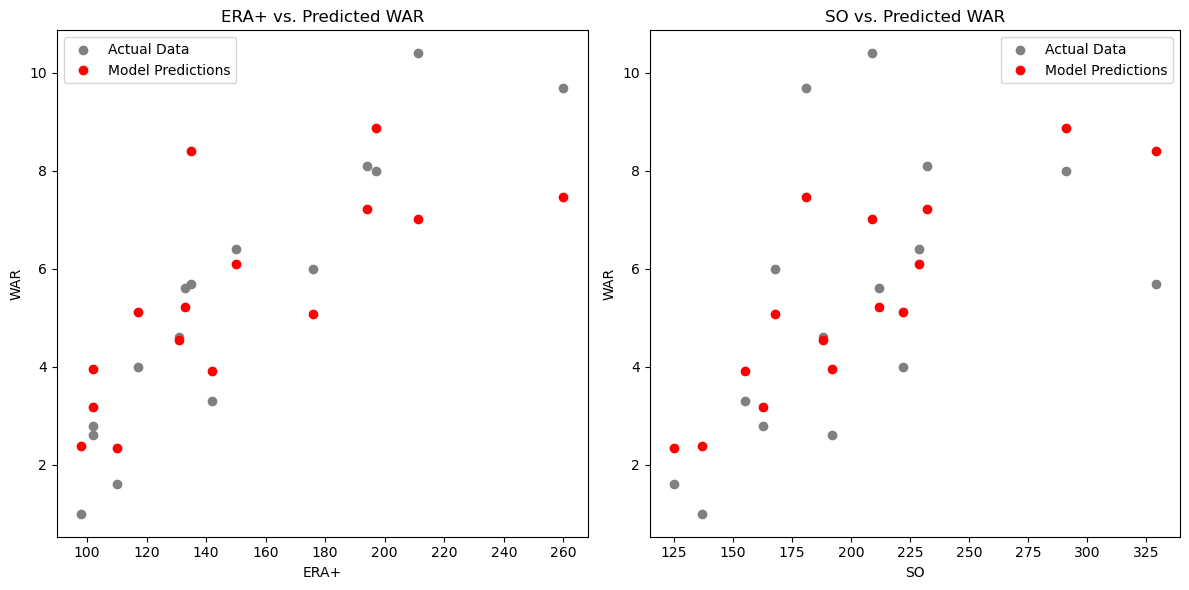

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# --- Plot 1: ERA+ vs. WAR ---

ax1.scatter(X_test['ERA+'], y_test, color='gray', label='Actual Data')

ax1.plot(X_test['ERA+'], predictions, 'o', color='red', label='Model Predictions')
ax1.set_title('ERA+ vs. Predicted WAR')
ax1.set_xlabel('ERA+')
ax1.set_ylabel('WAR')
ax1.legend()

# --- Plot 2: SO vs. WAR ---

ax2.scatter(X_test['SO'], y_test, color='gray', label='Actual Data')

ax2.plot(X_test['SO'], predictions, 'o', color='red', label='Model Predictions')
ax2.set_title('SO vs. Predicted WAR')
ax2.set_xlabel('SO')
ax2.set_ylabel('WAR')
ax2.legend()

plt.tight_layout()
plt.show()